In [2]:
# Importing Liraries
!pip install contextily -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from seaborn import color_palette
from copy import deepcopy
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 26.2 MB/s eta 0:00:00


In [3]:
## Display the first 5 rows
df = pd.read_csv('listings.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,56229,https://www.airbnb.com/rooms/56229,20241211032909,2024-12-12,city scrape,Cosy Double studio in Zone 2 Hammersmith (1),NaN,NaN,https://a0.muscache.com/pictures/3860587/79e73...,216660,...,4.79,4.92,4.71,NaN,f,11.0,9.0,1.0,0.0,0.84
1,62970,https://www.airbnb.com/rooms/62970,20241211032909,2024-12-12,city scrape,3 Bedrm with Garden off Brick lane refurbd Oct24,Recently renovated (Oct 2024) warehouse conve...,The neighbourhood is fantastic with Brick Lane...,https://a0.muscache.com/pictures/prohost-api/H...,336059,...,4.74,4.63,4.51,NaN,t,1.0,1.0,0.0,0.0,1.05
2,63948,https://www.airbnb.com/rooms/63948,20241211032909,2024-12-12,city scrape,Cosy Double studio in Zone 2 Hammersmith (4),NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,216660,...,4.78,4.91,4.60,NaN,f,11.0,9.0,1.0,0.0,1.06
3,66772,https://www.airbnb.com/rooms/66772,20241211032909,2024-12-11,city scrape,Cosy Double studio in Zone 2 Hammersmith (3),NaN,NaN,https://a0.muscache.com/pictures/c71a4e64-97f8...,216660,...,4.77,4.92,4.67,NaN,f,11.0,9.0,1.0,0.0,1.10
4,69198,https://www.airbnb.com/rooms/69198,20241211032909,2024-12-11,city scrape,Spacious single room in quiet flat,NaN,The flat is situated in a culturally vibrant a...,https://a0.muscache.com/pictures/6073529/f5cf9...,345886,...,4.85,4.62,4.23,NaN,f,1.0,0.0,1.0,0.0,0.09


In [4]:
## Displaying the data types
df.dtypes

,0
id,int64
listing_url,object
scrape_id,int64
last_scraped,object
source,object
...,...
calculated_host_listings_count,float64
calculated_host_listings_count_entire_homes,float64
calculated_host_listings_count_private_rooms,float64
calculated_host_listings_count_shared_rooms,float64


In [5]:
# Dropping some unnecessary columns
df.drop(['listing_url', 'id', 'scrape_id', 'last_scraped', 'source', 'host_id',
         'picture_url', 'name', 'host_since', 'host_url', 'host_name',
         'neighborhood_overview', 'description', 'host_thumbnail_url',
         'host_picture_url','host_about', 'host_verifications','neighbourhood',
         'calendar_last_scraped','first_review', 'last_review', 'host_location'], axis=1, inplace=True)

df.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.79,4.92,4.71,NaN,f,11.0,9.0,1.0,0.0,0.84
1,within a few hours,100%,100%,NaN,Mid-Beach,16.0,47.0,t,t,Tower Hamlets,...,4.74,4.63,4.51,NaN,t,1.0,1.0,0.0,0.0,1.05
2,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.78,4.91,4.60,NaN,f,11.0,9.0,1.0,0.0,1.06
3,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.77,4.92,4.67,NaN,f,11.0,9.0,1.0,0.0,1.10
4,NaN,NaN,NaN,f,NaN,1.0,1.0,t,t,Haringey,...,4.85,4.62,4.23,NaN,f,1.0,0.0,1.0,0.0,0.09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27530 entries, 0 to 27529
Data columns (total 53 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_response_time                            9828 non-null   object 
 1   host_response_rate                            9828 non-null   object 
 2   host_acceptance_rate                          11010 non-null  object 
 3   host_is_superhost                             27284 non-null  object 
 4   host_neighbourhood                            19910 non-null  object 
 5   host_listings_count                           27523 non-null  float64
 6   host_total_listings_count                     27523 non-null  float64
 7   host_has_profile_pic                          27523 non-null  object 
 8   host_identity_verified                        27523 non-null  object 
 9   neighbourhood_cleansed                        27529 non-null 

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
neighbourhood_group_cleansed,27530
license,27530
calendar_updated,27530
bathrooms,17917
price,17912
beds,17908
host_response_rate,17702
host_response_time,17702
host_acceptance_rate,16520
bedrooms,7929


In [8]:
df.isnull().mean().sort_values(ascending=False) * 100

,0
neighbourhood_group_cleansed,100.000000
license,100.000000
calendar_updated,100.000000
bathrooms,65.081729
price,65.063567
beds,65.049037
host_response_rate,64.300763
host_response_time,64.300763
host_acceptance_rate,60.007265
bedrooms,28.801308


In [9]:
df.drop(['neighbourhood_group_cleansed', 'license', 'calendar_updated'], axis=1, inplace=True)

df.isnull().mean().sort_values(ascending=False) * 100

,0
bathrooms,65.081729
price,65.063567
beds,65.049037
host_response_time,64.300763
host_response_rate,64.300763
host_acceptance_rate,60.007265
bedrooms,28.801308
host_neighbourhood,27.678896
review_scores_value,22.971304
review_scores_checkin,22.964039


In [10]:
# Identifying categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: ['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_neighbourhood', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'amenities', 'price', 'has_availability', 'instant_bookable']
Numerical Columns: ['host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculate

In [11]:
def fill_missing_values(df, columns):
    fill_values = {column: df[column].mean() for column in columns}
    df.fillna(fill_values, inplace=True)

# List of numerical columns to fill missing values
numerical_columns_to_fill = [
    'host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
    'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value', 'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms', 'reviews_per_month'
]

# Fill missing values
fill_missing_values(df, numerical_columns_to_fill)

In [12]:
def fill_missing_categorical_values(df, columns):
    # Check if the column exists in the DataFrame before filling missing values
    fill_values = {column: df[column].mode()[0] for column in columns if column in df.columns and df[column].mode().size > 0}
    df.fillna(fill_values, inplace=True)

# List of categorical columns to fill missing values
categorical_columns_to_fill = [
    'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_verifications',
    'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'property_type',
    'room_type', 'bathrooms_text', 'amenities', 'price', 'has_availability', 'calendar_last_scraped',
    'first_review', 'last_review', 'instant_bookable'
]

# Fill missing values
fill_missing_categorical_values(df, categorical_columns_to_fill)

# Print the head of the dataset to verify
df.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.88,4.79,4.92,4.71,f,11.0,9.0,1.0,0.0,0.84
1,within a few hours,100%,100%,f,Mid-Beach,16.0,47.0,t,t,Tower Hamlets,...,4.80,4.74,4.63,4.51,t,1.0,1.0,0.0,0.0,1.05
2,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.78,4.91,4.60,f,11.0,9.0,1.0,0.0,1.06
3,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.77,4.92,4.67,f,11.0,9.0,1.0,0.0,1.10
4,within an hour,100%,100%,f,Hampstead,1.0,1.0,t,t,Haringey,...,4.62,4.85,4.62,4.23,f,1.0,0.0,1.0,0.0,0.09


In [13]:
# Converting all column names to lowercase and replace the spaces with an underscore "_"
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [14]:
# Removing the dollar sign and comma from the columns of price and service_fee
df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True).astype(float)

In [15]:
df.isnull().sum().sort_values(ascending=False)

,0
host_response_time,0
host_response_rate,0
host_acceptance_rate,0
host_is_superhost,0
host_neighbourhood,0
host_listings_count,0
host_total_listings_count,0
host_has_profile_pic,0
host_identity_verified,0
neighbourhood_cleansed,0


In [16]:
df.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_l

In [17]:
df[['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
    'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms','beds',
    'amenities', 'price', 'minimum_nights', 'maximum_nights','minimum_minimum_nights',
    'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'number_of_reviews_l30d', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness']].head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,...,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness
0,Hammersmith and Fulham,51.49392,-0.22754,Entire rental unit,Entire home/apt,2.0,1.5,1.5 baths,1.0,1.0,...,2.0,8.0,11.0,22.0,145.0,42.0,1.0,4.71,4.71,4.67
1,Tower Hamlets,51.52435,-0.06938,Entire condo,Entire home/apt,6.0,3.0,3 baths,3.0,3.0,...,13.0,23.0,53.0,326.0,178.0,3.0,1.0,4.52,4.64,4.60
2,Hammersmith and Fulham,51.49547,-0.22864,Entire rental unit,Entire home/apt,2.0,1.0,1 bath,1.0,1.0,...,0.0,7.0,12.0,149.0,170.0,57.0,1.0,4.61,4.62,4.69
3,Hammersmith and Fulham,51.49368,-0.22774,Room in aparthotel,Private room,2.0,1.0,1 private bath,1.0,1.0,...,9.0,32.0,45.0,62.0,186.0,44.0,2.0,4.65,4.76,4.76
4,Haringey,51.59031,-0.09408,Private room in rental unit,Private room,1.0,1.0,1 shared bath,1.0,1.0,...,28.0,58.0,88.0,363.0,13.0,0.0,0.0,4.46,4.69,4.77


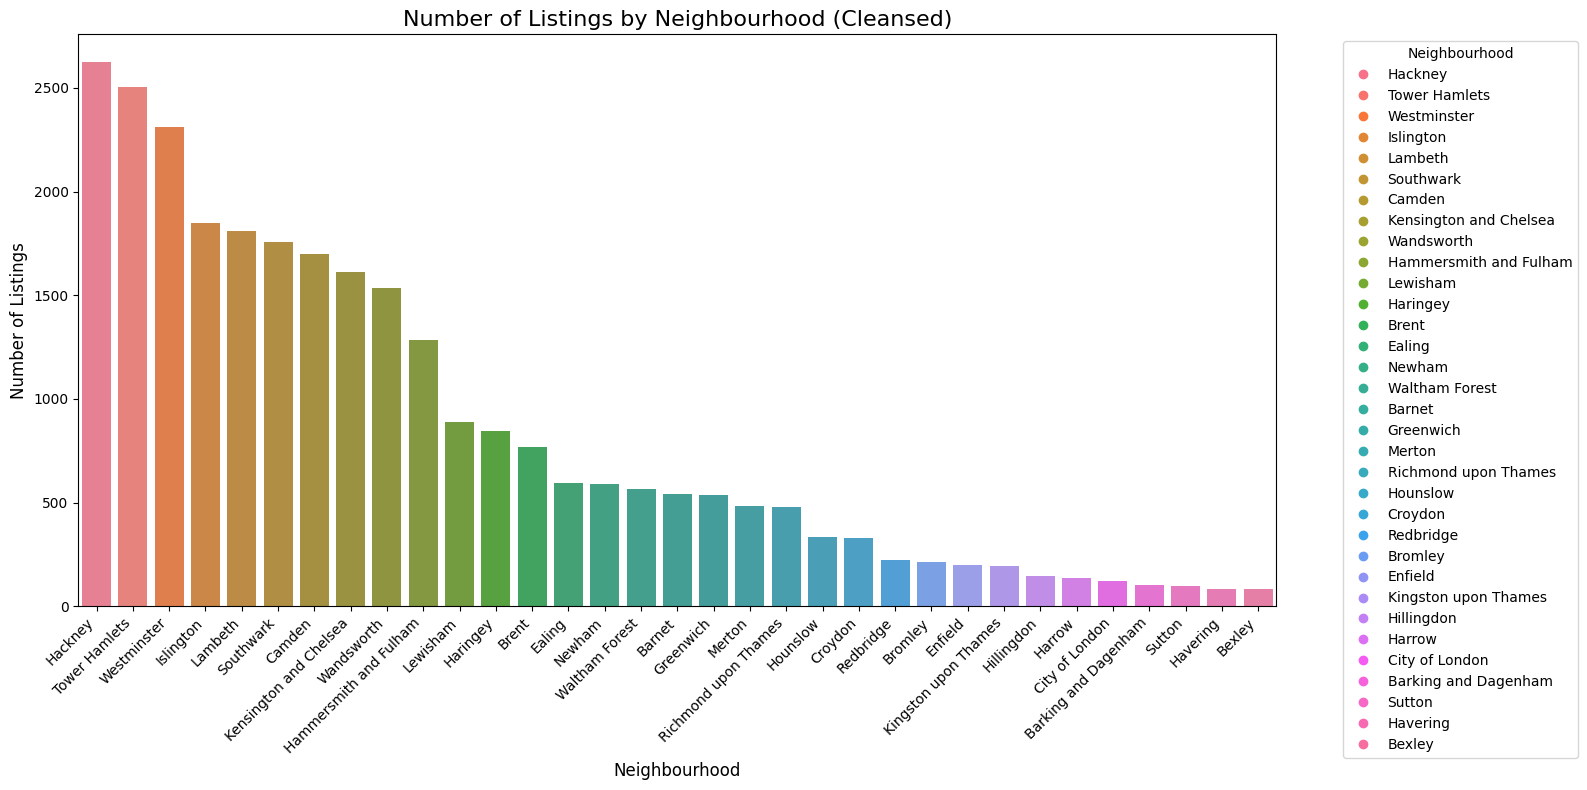

In [18]:
# Count the occurrences of each unique value in 'neighbourhood_cleansed'
neighbourhood_counts = df['neighbourhood_cleansed'].value_counts()

# Generate a color palette with as many colors as there are unique neighbourhoods
colors = color_palette("husl", len(neighbourhood_counts))

# Create a bar plot with seaborn
plt.figure(figsize=(16, 8))  # Increased width for better readability
sns.barplot(x=neighbourhood_counts.index, y=neighbourhood_counts.values, palette=colors, hue=neighbourhood_counts.index, dodge=False, legend=False)

# Add title and labels
plt.title('Number of Listings by Neighbourhood (Cleansed)', fontsize=16)
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a legend outside the graph
# Create a legend with both neighborhood names and corresponding colors
handles = [plt.Line2D([0], [0], marker='o', color=color, label=neighbourhood, linestyle='')
           for color, neighbourhood in zip(colors, neighbourhood_counts.index)]
plt.legend(title="Neighbourhood", handles=handles, loc='upper left', bbox_to_anchor=(1.05, 1))

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

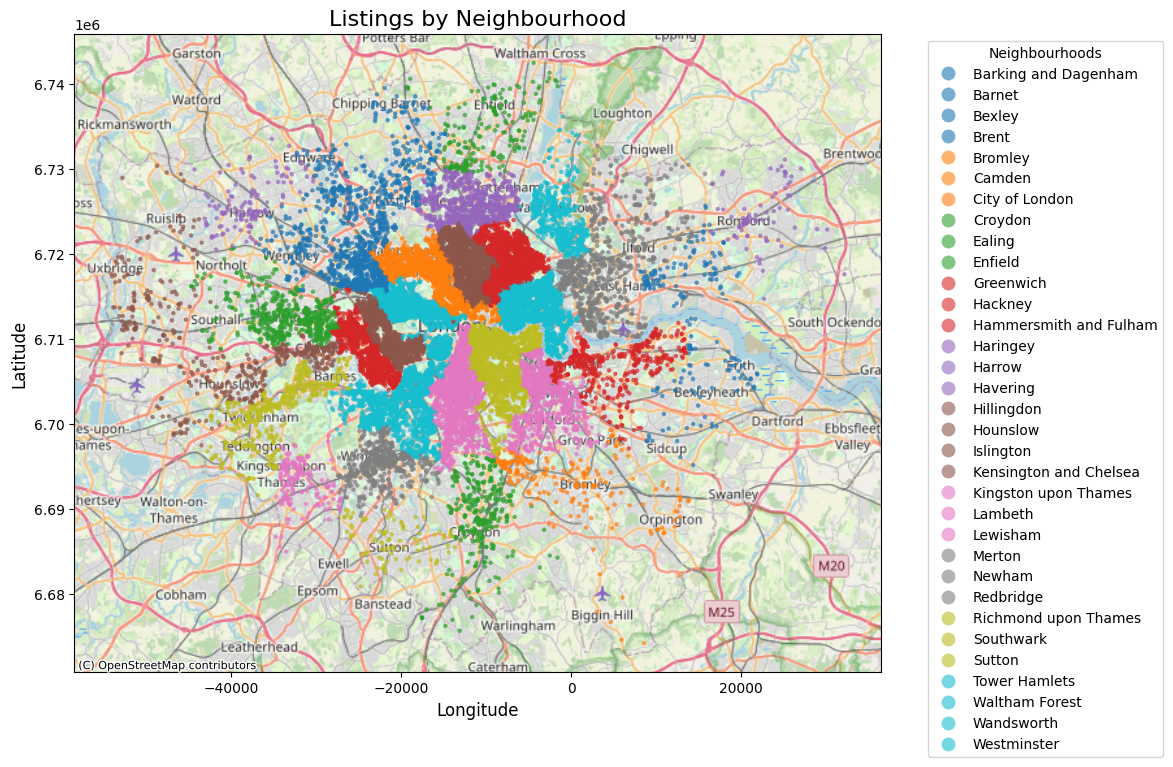

In [19]:
# Create a GeoDataFrame from the DataFrame
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
geo_df = gpd.GeoDataFrame(df, geometry=geometry)

# Set the coordinate reference system (CRS) to WGS84 (EPSG:4326)
geo_df.set_crs(epsg=4326, inplace=True)

# Convert to Web Mercator (EPSG:3857) for compatibility with contextily
geo_df = geo_df.to_crs(epsg=3857)

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(12, 8))
geo_df.plot(ax=ax, markersize=5, alpha=0.6, column='neighbourhood_cleansed', legend=True)

# Add a basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Add title and labels
ax.set_title('Listings by Neighbourhood', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Move the legend outside of the graph
legend = ax.get_legend()
if legend:
    legend.set_bbox_to_anchor((1.05, 1))
    legend.set_title("Neighbourhoods")

plt.tight_layout()
plt.show()

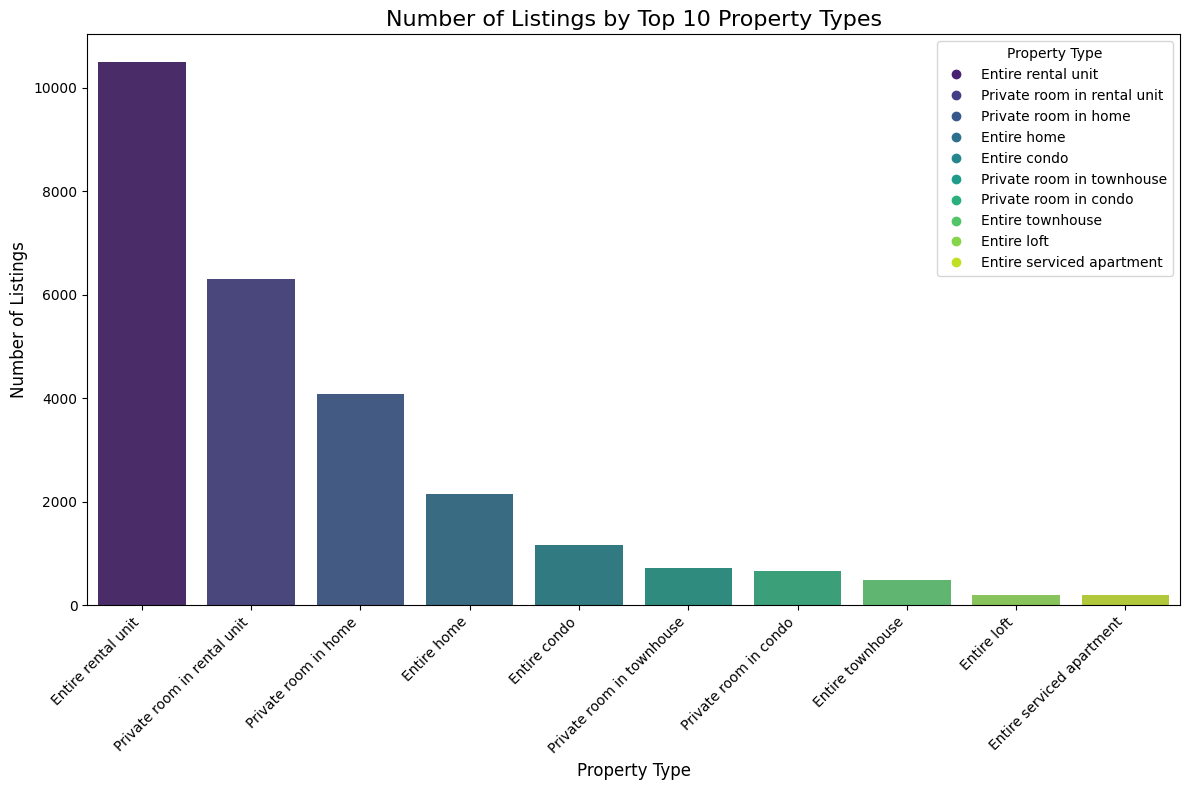

In [20]:
# Ensure "property_type_counts" is defined
property_type_counts = df['property_type'].value_counts()

# Select the top 10 property types
top_property_types = property_type_counts.head(10)

# Create a bar plot with seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x=top_property_types.index, y=top_property_types.values,
            hue=top_property_types.index, palette="viridis", dodge=False,
            legend=False)

# Add title and labels
plt.title('Number of Listings by Top 10 Property Types', fontsize=16)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add legend manually
handles = [plt.Line2D([0], [0], marker='o', color=color, label=ptype, linestyle='')
           for color, ptype in zip(sns.color_palette("viridis", len(top_property_types)),
                                   top_property_types.index)]
plt.legend(title="Property Type", handles=handles, loc='upper right')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

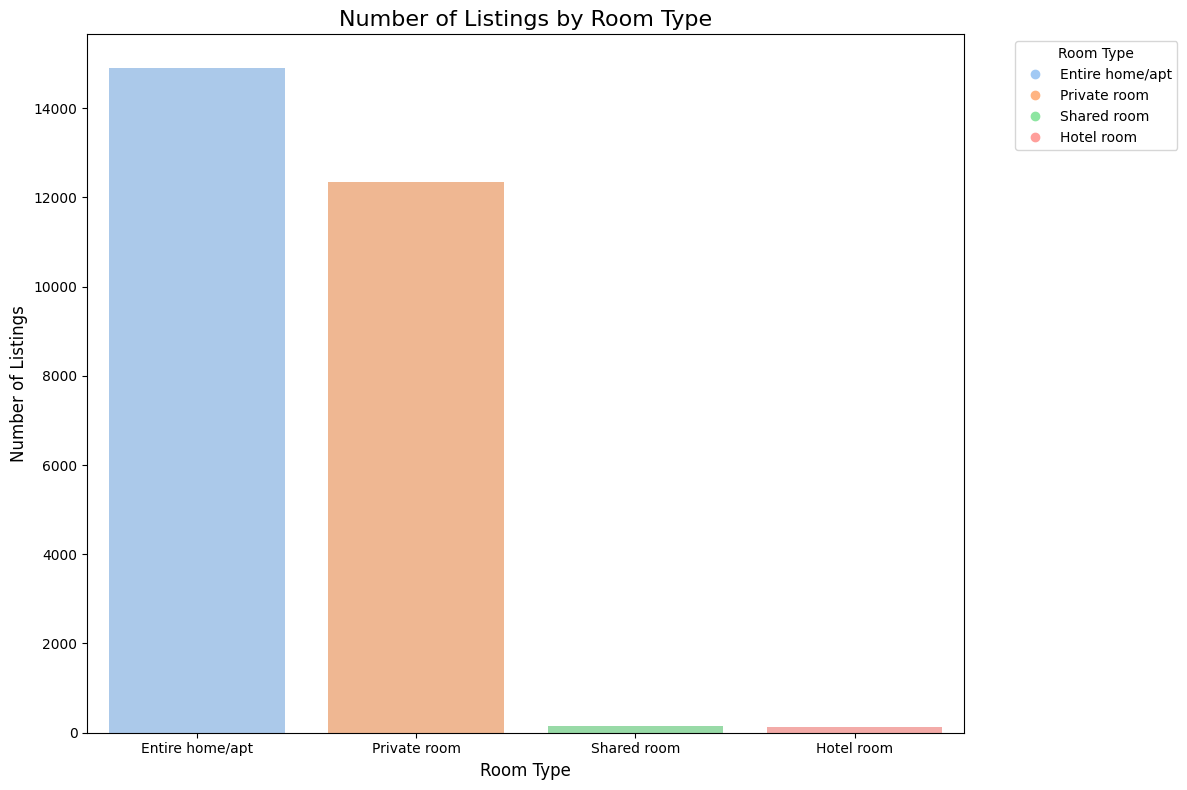

In [21]:
# Count the occurrences of each unique value in 'room_type'
room_type_counts = df['room_type'].value_counts()

# Create a bar plot with seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x=room_type_counts.index, y=room_type_counts.values, hue=room_type_counts.index, palette="pastel", dodge=False)

# Add title and labels
plt.title('Number of Listings by Room Type', fontsize=16)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Create a legend with room types and corresponding colors
handles = [plt.Line2D([0], [0], marker='o', color=color, label=room_type, linestyle='')
           for color, room_type in zip(sns.color_palette("pastel", len(room_type_counts)), room_type_counts.index)]
plt.legend(title="Room Type", handles=handles, loc='upper left', bbox_to_anchor=(1.05, 1))

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [22]:
df[['bathrooms_text', 'bedrooms','beds', 'amenities', 'price', 'minimum_nights',
    'maximum_nights','minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60',
    'availability_90']].head()

,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90
0,1.5 baths,1.0,1.0,"[""Cooking basics"", ""Fire extinguisher"", ""Dryer...",89.0,5.0,365.0,1.0,7.0,365.0,365.0,4.1,365.0,t,2.0,8.0,11.0
1,3 baths,3.0,3.0,"[""Cooking basics"", ""Dryer"", ""Stove"", ""Patio or...",220.0,1.0,1125.0,1.0,3.0,2.0,1125.0,2.9,793.7,t,13.0,23.0,53.0
2,1 bath,1.0,1.0,"[""Cooking basics"", ""Fire extinguisher"", ""Dryer...",88.0,3.0,730.0,1.0,3.0,730.0,730.0,3.0,730.0,t,0.0,7.0,12.0
3,1 private bath,1.0,1.0,"[""Cooking basics"", ""Fire extinguisher"", ""Stove...",75.0,3.0,1125.0,1.0,3.0,1125.0,1125.0,2.8,1125.0,t,9.0,32.0,45.0
4,1 shared bath,1.0,1.0,"[""Wifi"", ""Hot water"", ""Washer"", ""Breakfast"", ""...",53.0,3.0,730.0,3.0,3.0,730.0,730.0,3.0,730.0,t,28.0,58.0,88.0


In [23]:
df['bathrooms_text'].unique()

array(['1.5 baths', '3 baths', '1 bath', '1 private bath',
       '1 shared bath', '2 baths', '2.5 baths', '1.5 shared baths',
       'Shared half-bath', '0 shared baths', '2.5 shared baths',
       '0 baths', '2 shared baths', '4 baths', '3 shared baths',
       '3.5 baths', 'Half-bath', '4.5 baths', '5 shared baths',
       '3.5 shared baths', '5 baths', '4 shared baths', '6 baths',
       '5.5 baths', '10 baths', 'Private half-bath', '7 shared baths',
       '8 shared baths', '6.5 baths', '7.5 baths', '10 shared baths',
       '10.5 baths'], dtype=object)

In [24]:
df['bathrooms_text'].value_counts()

,count
bathrooms_text,
1 bath,12217
1 shared bath,5004
2 baths,3044
1 private bath,2303
1.5 baths,1760
1.5 shared baths,1008
2.5 baths,733
2 shared baths,426
3 baths,329


In [25]:
df['host_is_superhost'].value_counts()

,count
host_is_superhost,
f,23475
t,4055


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [28]:
df.shape

(27530, 50)

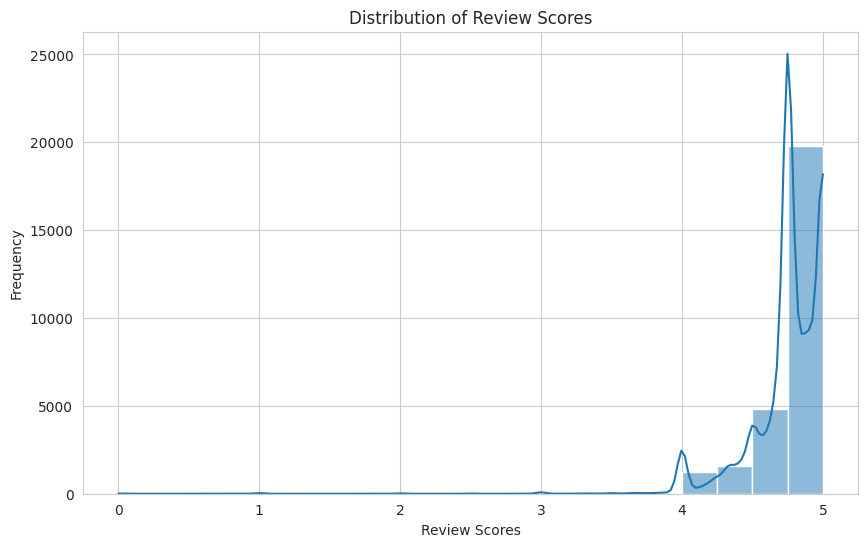

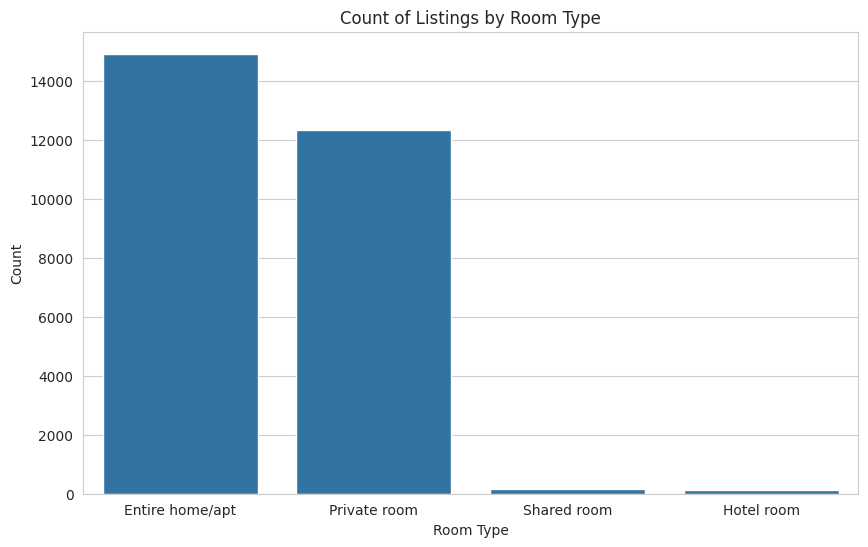

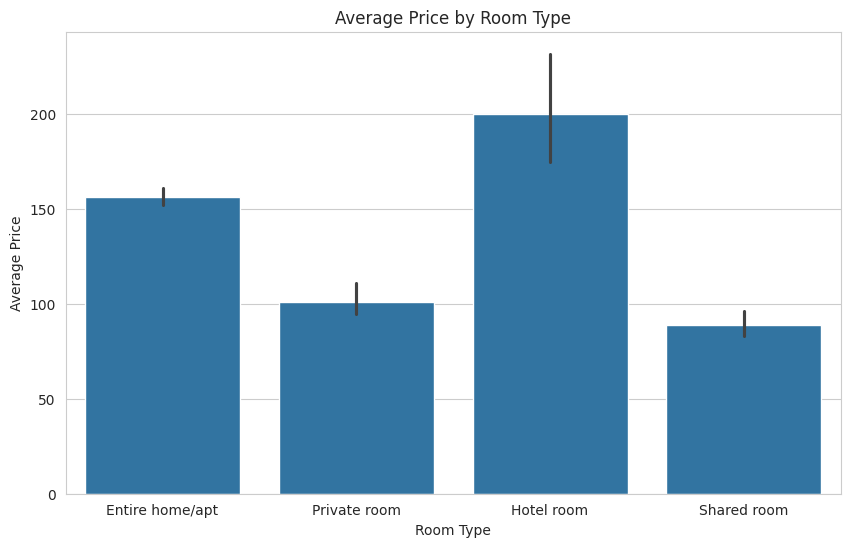

In [29]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Plot the distribution of review scores
plt.figure(figsize=(10, 6))
sns.histplot(df['review_scores_rating'], bins=20, kde=True)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Scores')
plt.ylabel('Frequency')
plt.show()

# Plot the count of listings by room type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index)
plt.title('Count of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# Plot the average price by room type
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='room_type', y=df['price'])
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.show()

In [30]:
df1 = deepcopy(df)

In [31]:
df1.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.88,4.79,4.92,4.71,f,11.0,9.0,1.0,0.0,0.84
1,within a few hours,100%,100%,f,Mid-Beach,16.0,47.0,t,t,Tower Hamlets,...,4.80,4.74,4.63,4.51,t,1.0,1.0,0.0,0.0,1.05
2,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.78,4.91,4.60,f,11.0,9.0,1.0,0.0,1.06
3,within a day,99%,95%,f,Hammersmith,11.0,11.0,t,t,Hammersmith and Fulham,...,4.87,4.77,4.92,4.67,f,11.0,9.0,1.0,0.0,1.10
4,within an hour,100%,100%,f,Hampstead,1.0,1.0,t,t,Haringey,...,4.62,4.85,4.62,4.23,f,1.0,0.0,1.0,0.0,0.09


In [32]:
df1.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_l

In [33]:
df1.dropna(subset=['price'], inplace=True)

In [34]:
# Dropping 'host_neighbourhood','amenities','latitude','longitude'
df1.drop(['host_neighbourhood','amenities','latitude','longitude'], axis=1, inplace=True)
df1.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,within a day,99%,95%,f,11.0,11.0,t,t,Hammersmith and Fulham,Entire rental unit,...,4.88,4.79,4.92,4.71,f,11.0,9.0,1.0,0.0,0.84
1,within a few hours,100%,100%,f,16.0,47.0,t,t,Tower Hamlets,Entire condo,...,4.80,4.74,4.63,4.51,t,1.0,1.0,0.0,0.0,1.05
2,within a day,99%,95%,f,11.0,11.0,t,t,Hammersmith and Fulham,Entire rental unit,...,4.87,4.78,4.91,4.60,f,11.0,9.0,1.0,0.0,1.06
3,within a day,99%,95%,f,11.0,11.0,t,t,Hammersmith and Fulham,Room in aparthotel,...,4.87,4.77,4.92,4.67,f,11.0,9.0,1.0,0.0,1.10
4,within an hour,100%,100%,f,1.0,1.0,t,t,Haringey,Private room in rental unit,...,4.62,4.85,4.62,4.23,f,1.0,0.0,1.0,0.0,0.09


In [35]:
split = df1[['host_identity_verified','room_type', 'instant_bookable',
             'minimum_nights', 'availability_365','accommodates',
             'bathrooms', 'bedrooms', 'beds','number_of_reviews',
             'calculated_host_listings_count', 'price']]

split.head()

,host_identity_verified,room_type,instant_bookable,minimum_nights,availability_365,accommodates,bathrooms,bedrooms,beds,number_of_reviews,calculated_host_listings_count,price
0,t,Entire home/apt,f,5.0,22.0,2.0,1.5,1.0,1.0,145.0,11.0,89.0
1,t,Entire home/apt,t,1.0,326.0,6.0,3.0,3.0,3.0,178.0,1.0,220.0
2,t,Entire home/apt,f,3.0,149.0,2.0,1.0,1.0,1.0,170.0,11.0,88.0
3,t,Private room,f,3.0,62.0,2.0,1.0,1.0,1.0,186.0,11.0,75.0
4,t,Private room,f,3.0,363.0,1.0,1.0,1.0,1.0,13.0,1.0,53.0


<Axes: >

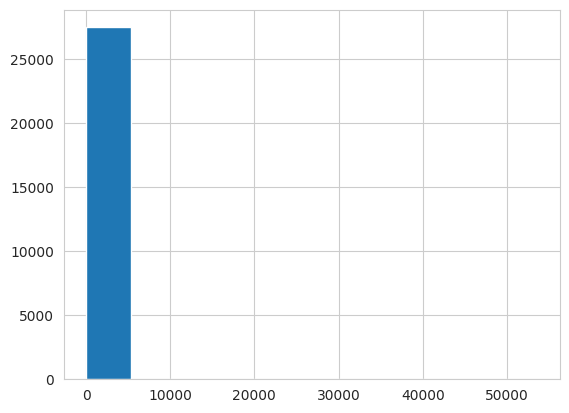

In [36]:
split['price'].hist()

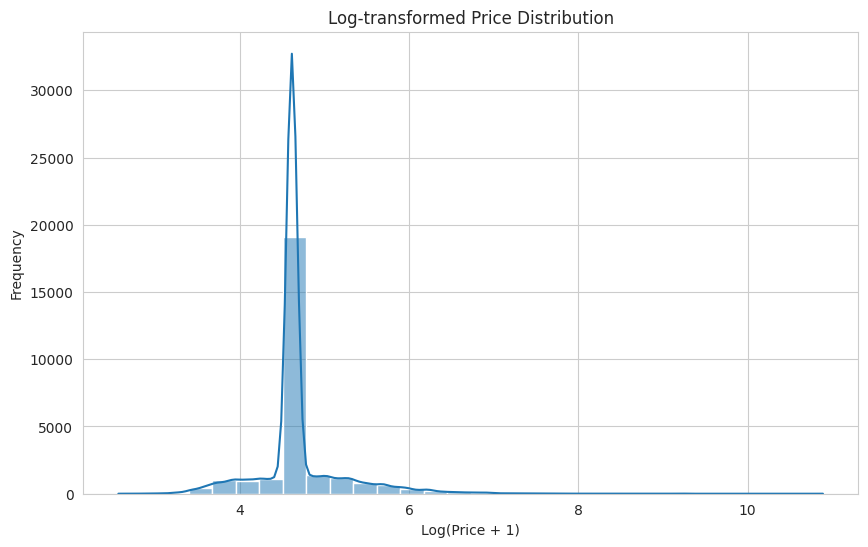

In [37]:
# Apply log transformation to reduce right skewness
split['price'] = np.log1p(split['price'])

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(split['price'], bins=30, kde=True)
plt.title('Log-transformed Price Distribution')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

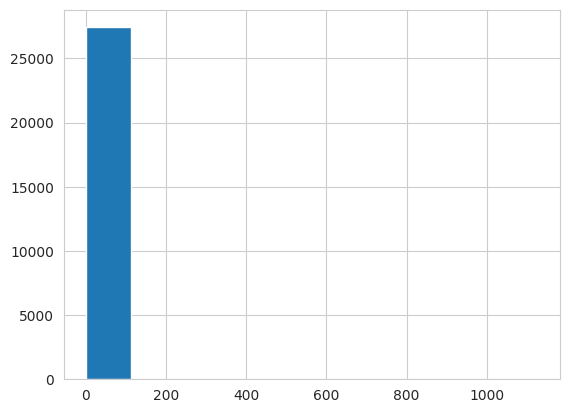

In [38]:
split['minimum_nights'].hist()

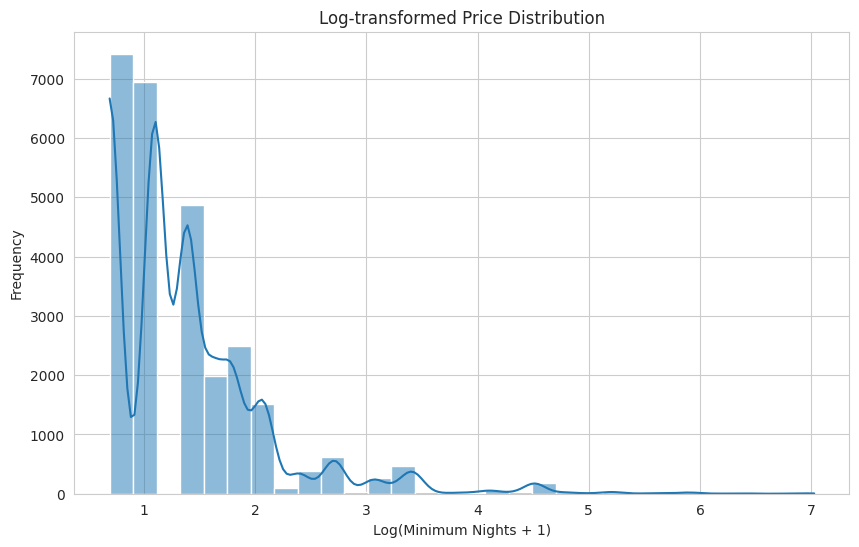

In [39]:
# Apply log transformation to reduce right skewness
split['minimum_nights'] = np.log1p(split['minimum_nights'])

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(split['minimum_nights'], bins=30, kde=True)
plt.title('Log-transformed Price Distribution')
plt.xlabel('Log(Minimum Nights + 1)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

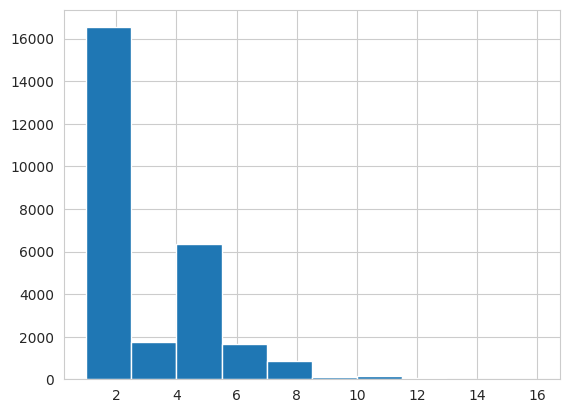

In [40]:
split['accommodates'].hist()

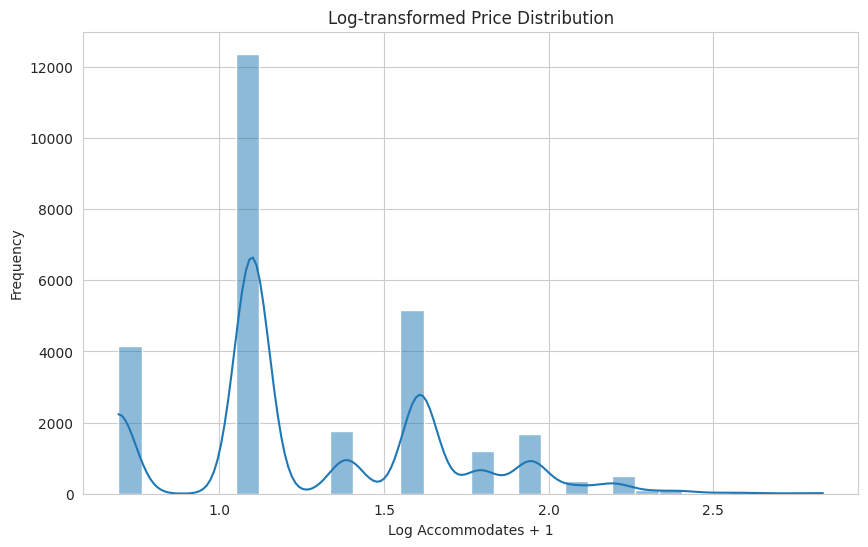

In [41]:
# Apply log transformation to reduce right skewness
split['accommodates'] = np.log1p(split['accommodates'])

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(split['accommodates'], bins=30, kde=True)
plt.title('Log-transformed Price Distribution')
plt.xlabel('Log Accommodates + 1')
plt.ylabel('Frequency')
plt.show()

<Axes: >

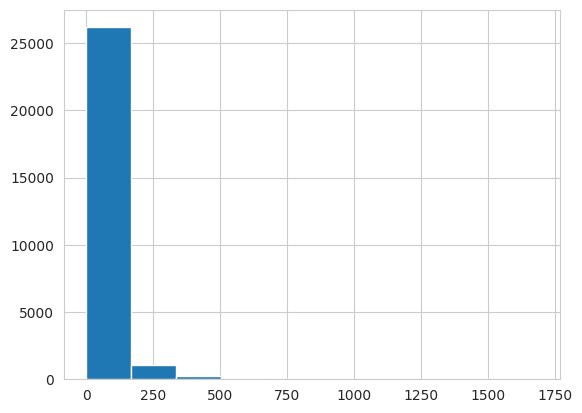

In [42]:
split['number_of_reviews'].hist()

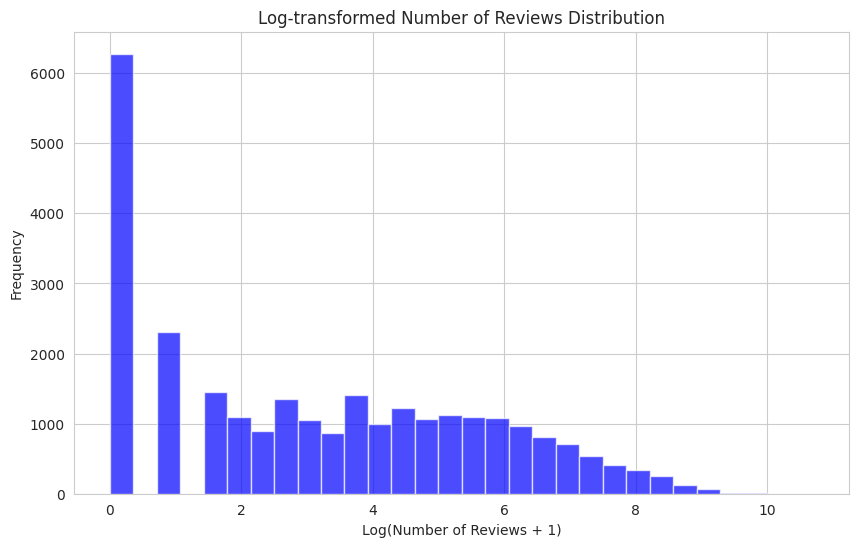

In [43]:
split.loc[:, 'number_of_reviews'] = np.log2(split['number_of_reviews'] + 1)

# Plot the transformed price distribution
plt.figure(figsize=(10, 6))
plt.hist(split['number_of_reviews'], bins=30, color='blue', alpha=0.7)
plt.title('Log-transformed Number of Reviews Distribution')
plt.xlabel('Log(Number of Reviews + 1)')
plt.ylabel('Frequency')
plt.show()

In [44]:
split['bathrooms'] = split['bathrooms'].fillna(0).astype(int)
split['bedrooms'] = split['bedrooms'].fillna(0).astype(int)
split['beds'] = split['beds'].fillna(0).astype(int)

split[['bathrooms', 'bedrooms', 'beds']].head()

,bathrooms,bedrooms,beds
0,1,1,1
1,3,3,3
2,1,1,1
3,1,1,1
4,1,1,1


In [45]:
split.head()

,host_identity_verified,room_type,instant_bookable,minimum_nights,availability_365,accommodates,bathrooms,bedrooms,beds,number_of_reviews,calculated_host_listings_count,price
0,t,Entire home/apt,f,1.791759,22.0,1.098612,1,1,1,7.189825,11.0,4.499810
1,t,Entire home/apt,t,0.693147,326.0,1.945910,3,3,3,7.483816,1.0,5.398163
2,t,Entire home/apt,f,1.386294,149.0,1.098612,1,1,1,7.417853,11.0,4.488636
3,t,Private room,f,1.386294,62.0,1.098612,1,1,1,7.546894,11.0,4.330733
4,t,Private room,f,1.386294,363.0,0.693147,1,1,1,3.807355,1.0,3.988984


In [46]:
split_num_cols = [['minimum_nights', 'availability_365', 'accommodates',
                   'number_of_reviews', 'calculated_host_listings_count',
                   'price']]
split_cat_cols = [['host_identity_verified', 'room_type', 'instant_bookable',
                   'bathrooms','bedrooms', 'beds']]
split_num_cols, split_cat_cols

([['minimum_nights',
   'availability_365',
   'accommodates',
   'number_of_reviews',
   'calculated_host_listings_count',
   'price']],
 [['host_identity_verified',
   'room_type',
   'instant_bookable',
   'bathrooms',
   'bedrooms',
   'beds']])

In [47]:
# Perform ordinal encoding on categorical columns
oe = OrdinalEncoder()
split[split_cat_cols[0]] = oe.fit_transform(split[split_cat_cols[0]])

# Perform robust scaling on numerical columns
rs = RobustScaler()
split[split_num_cols[0]] = rs.fit_transform(split[split_num_cols[0]])
split.head()

,host_identity_verified,room_type,instant_bookable,minimum_nights,availability_365,accommodates,bathrooms,bedrooms,beds,number_of_reviews,calculated_host_listings_count,price
0,1.0,0.0,0.0,0.756471,0.258824,0.000000,1.0,1.0,1.0,0.986322,10.0,-0.115311
1,1.0,0.0,1.0,-0.442507,3.835294,1.658683,3.0,3.0,3.0,1.055530,0.0,0.783042
2,1.0,0.0,0.0,0.313964,1.752941,0.000000,1.0,1.0,1.0,1.040002,10.0,-0.126484
3,1.0,2.0,0.0,0.313964,0.729412,0.000000,1.0,1.0,1.0,1.070379,10.0,-0.284387
4,1.0,2.0,0.0,0.313964,4.270588,-0.793745,1.0,1.0,1.0,0.190059,0.0,-0.626136


In [48]:
X = split.drop(columns=['price'])
y = split['price']

# training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

rfr = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=2)

# Fit the model
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [49]:
# Make predictions
y_pred = rfr.predict(X_test)

# Evaluate the model
rfr_mse = mean_squared_error(y_test, y_pred)
rfr_r2 = r2_score(y_test, y_pred)
rfr_rmse = np.sqrt(rfr_mse)
rfr_mae = mean_absolute_error(y_test, y_pred)
rfr_mape = mean_absolute_percentage_error(y_test, y_pred)

# Print the evaluation metrics
print("Random Forest Regressor")
print("=========================")
print(f"MSE: {rfr_mse:.2f}")
print(f"RMSE: {rfr_rmse:.2f}")
print(f"R2: {rfr_r2:.2f}")
print(f"MAE: {rfr_mae:.2f}")
print(f"MAPE: {rfr_mape:.2f}")

Random Forest Regressor
MSE: 0.09
RMSE: 0.30
R2: 0.63
MAE: 0.13
MAPE: 37101368337336.59


In [50]:
# Define the model
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)


# Fit the model
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [51]:
# Make predictions
y_pred_gbr = gbr.predict(X_test)
# Evaluate the model
gbr_mse = mean_squared_error(y_test, y_pred_gbr)
gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(gbr_mse)
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_mape = mean_absolute_percentage_error(y_test, y_pred_gbr)

# Print the evaluation metrics
print("Gradient Boosting Regressor")
print("=========================")
print(f"MSE: {gbr_mse:.2f}")
print(f"RMSE: {gbr_rmse:.2f}")
print(f"R2: {gbr_r2:.2f}")
print(f"MAE: {gbr_mae:.2f}")
print(f"MAPE: {gbr_mape:.2f}")

Gradient Boosting Regressor
MSE: 0.10
RMSE: 0.31
R2: 0.61
MAE: 0.14
MAPE: 62802946001099.30


In [52]:
# Create a new pipeline with a different model (e.g., Linear Regression)
from sklearn.linear_model import LinearRegression

# Define the model
lr = LinearRegression()

# Fit the model
lr.fit(X_train, y_train)

LinearRegression()

In [53]:
# Make predictions
y_pred_lr = lr.predict(X_test)

# Evaluate the model
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr)

# Print the evaluation metrics
print("Linear Regression")
print("=========================")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R2: {lr_r2:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"MAPE: {lr_mape:.2f}")

Linear Regression
MSE: 0.15
RMSE: 0.39
R2: 0.38
MAE: 0.25
MAPE: 387106640780152.25


In [54]:
# Define the model
dtr = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=2)
# Fit the model
dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [55]:
# Make predictions
y_pred_dtr = dtr.predict(X_test)
# Evaluate the model
dtr_mse = mean_squared_error(y_test, y_pred_dtr)
dtr_r2 = r2_score(y_test, y_pred_dtr)
dtr_rmse = np.sqrt(dtr_mse)
dtr_mae = mean_absolute_error(y_test, y_pred_dtr)
dtr_mape = mean_absolute_percentage_error(y_test, y_pred_dtr)
# Print the evaluation metrics
print("Decision Tree Regressor")
print("=========================")
print(f"MSE: {dtr_mse:.2f}")
print(f"RMSE: {dtr_rmse:.2f}")
print(f"R2: {dtr_r2:.2f}")
print(f"MAE: {dtr_mae:.2f}")
print(f"MAPE: {dtr_mape:.2f}")

Decision Tree Regressor
MSE: 0.12
RMSE: 0.34
R2: 0.53
MAE: 0.14
MAPE: 39706478030426.96


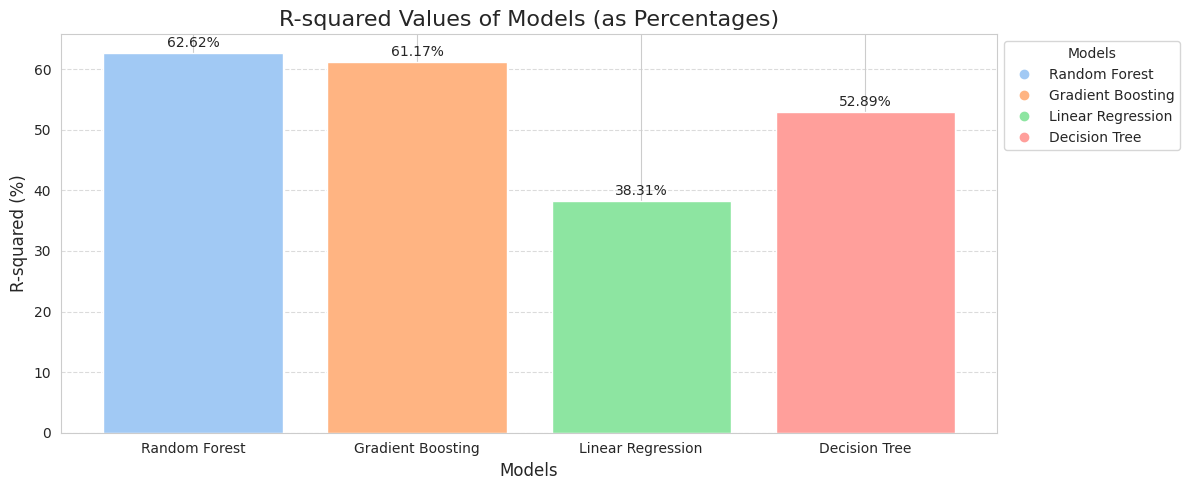

In [56]:
# Define the models and ensure that rfr_sc is defined by computing the score from the Random Forest pipeline if needed
models = ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Decision Tree']

r_squared_values = [rfr_r2, gbr_r2, lr_r2, dtr_r2]

# Convert R-squared values to percentages
r_squared_percentages = [value * 100 for value in r_squared_values]

# Create the bar chart
plt.figure(figsize=(12, 5))
bars = plt.bar(models, r_squared_percentages, color=sns.color_palette("pastel", len(models)))

# Add labels and title
plt.title('R-squared Values of Models (as Percentages)', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('R-squared (%)', fontsize=12)

# Add percentage labels on top of the bars
for bar, percentage in zip(bars, r_squared_percentages):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{percentage:.2f}%', ha='center', fontsize=10)

# Add a legend outside the chart
handles = [plt.Line2D([0], [0], marker='o', color=bar.get_facecolor(), label=model, linestyle='')
           for bar, model in zip(bars, models)]
plt.legend(title="Models", handles=handles, loc='upper left', bbox_to_anchor=(1, 1))

# Adjust layout and show the plot
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [57]:
import joblib

# Save the random forest model weights
model_filename = 'random_forest_model.joblib'
joblib.dump(rfr, model_filename)

['random_forest_model.joblib']

In [58]:
# Load the saved model
loaded_model = joblib.load('random_forest_model.joblib')

# Sample input data (replace with actual data)
sample_input_1 = [1, 0, 0, 1.0986, 6.0, 2.0, 1.0, 2.0, 1.0, 2.0, 0]
sample_input_2 = [0, 1, 1, 1.3863, 5.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1]

# Reshape the input data
sample_input_1 = np.array(sample_input_1).reshape(1, -1)
sample_input_2 = np.array(sample_input_2).reshape(1, -1)

# Make predictions
prediction_1 = loaded_model.predict(sample_input_1)
prediction_2 = loaded_model.predict(sample_input_2)


print(f"Prediction for sample input 1: {prediction_1}")
print(f"Prediction for sample input 2: {prediction_2}")

Prediction for sample input 1: [0.61636376]
Prediction for sample input 2: [0.91219566]
